# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** KUKUWA AMOAH
**Student ID:** 34122028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [32]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42


torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

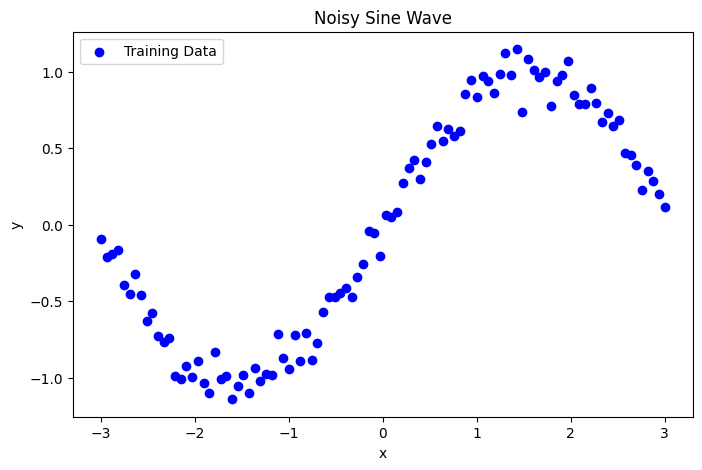

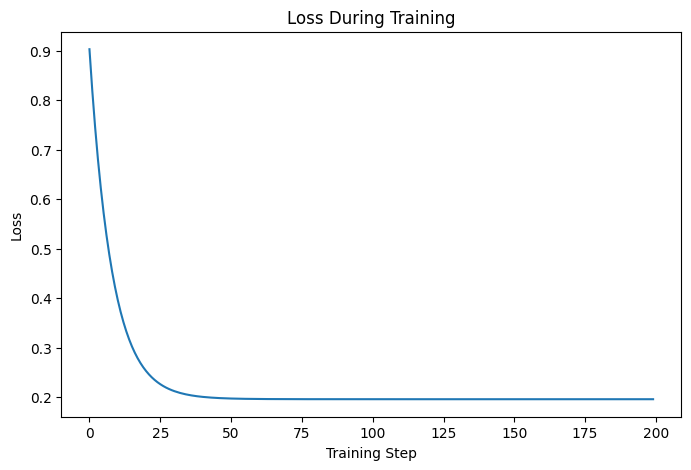

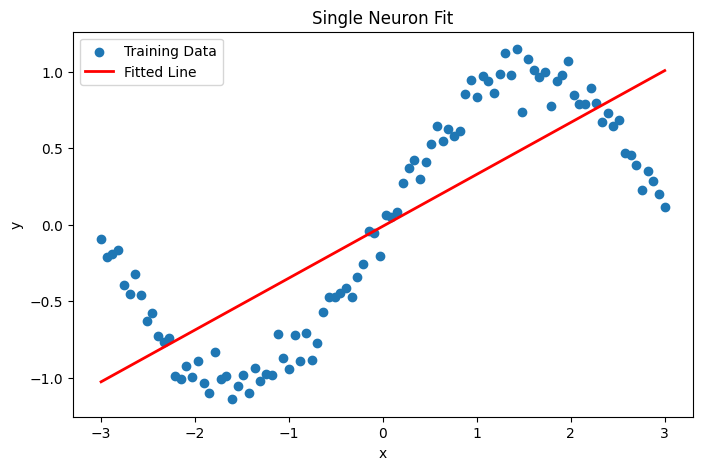

Final weight (w): 0.3390
Final bias (b): -0.0109
Final loss: 0.1955


In [33]:

x = np.linspace(-3, 3, 100)


noise = np.random.normal(0, 0.1, size=x.shape)


y = np.sin(x) + noise

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', label='Training Data')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy Sine Wave")
plt.legend()
plt.show()

w = np.random.randn() * 0.1
b = np.random.randn() * 0.1


lr = 0.01

epochs = 200

loss_history = []

for epoch in range(epochs):

  
    y_hat = w * x + b

    loss = np.mean((y_hat - y) ** 2)

   
    loss_history.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

  
    w -= lr * dw
    b -= lr * db


plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss During Training")
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Training Data")
plt.plot(x, w * x + b, color='red', linewidth=2, label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single Neuron Fit")
plt.legend()
plt.show()


print(f"Final weight (w): {w:.4f}")
print(f"Final bias (b): {b:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")

**Student Reasoning — The single neuron**

![Gradient Derivation](derived.jpg)

This matches the code because it calculates the same gradient using the average.

2. This is underfitting because the model cannot capture the shape of the sine wave. The loss decreases, but the fitted line is still a straight line. A single neuron can only learn a linear relationship, while a sine wave is nonlinear.







### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

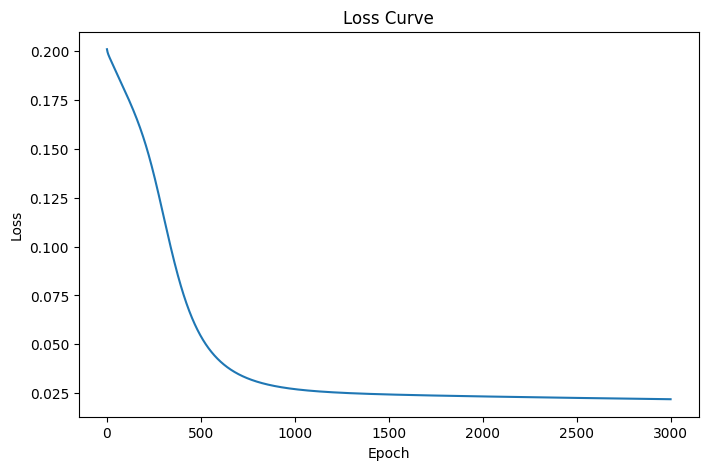

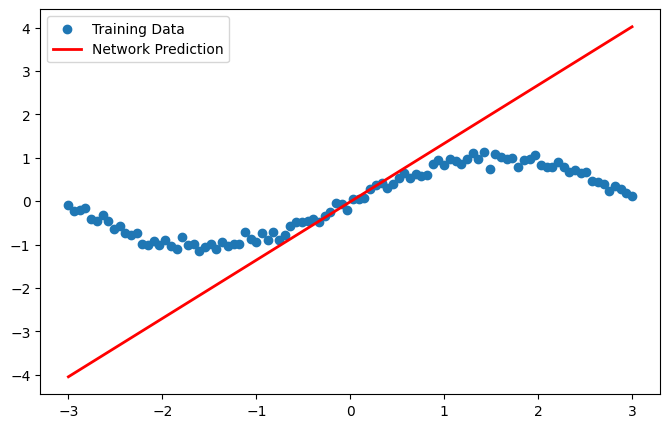

In [34]:

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
epochs = 3000

loss_history = []

x_train = x.reshape(-1, 1)
y_train = y.reshape(-1, 1)

for epoch in range(epochs):
    z1 = x_train @ W1 + b1
    h = np.tanh(z1)

    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_train) ** 2)
    loss_history.append(loss)


    d_yhat = 2 * (y_hat - y_train) / len(y_train)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x_train.T @ dz1
    db1 = dz1.sum(axis=0)


    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2


plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Training Data")

z1 = x_train @ W1 + b1
h = z1
y_pred = h @ W2 + b2

plt.plot(x, y_pred, color="red", linewidth=2, label="Network Prediction")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
1. When the tanh activation function is removed, every layer in the network becomes linear meaning that the multiple layers combine to behave like one single linear layer. so, the network can only produce a straight-line relationship, just like the single neuron in Part 1.1. Since a sine wave is curved, the network cannot learn its shape without a nonlinear activation function.

2. The 8 hidden neurons learned different parts of the input and they helped the network create a curve that matched the sine wave

3. Backpropagation is calculating gradients so the network can update its weights and reduce the error

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/g9/k_k0q_ns4813hc9m107ghh080000gn/T/ipykernel_41813/162552126.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_train) ** 2)
/var/folders/g9/k_k0q_ns4813hc9m107ghh080000gn/T/ipykernel_41813/162552126.py:31: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


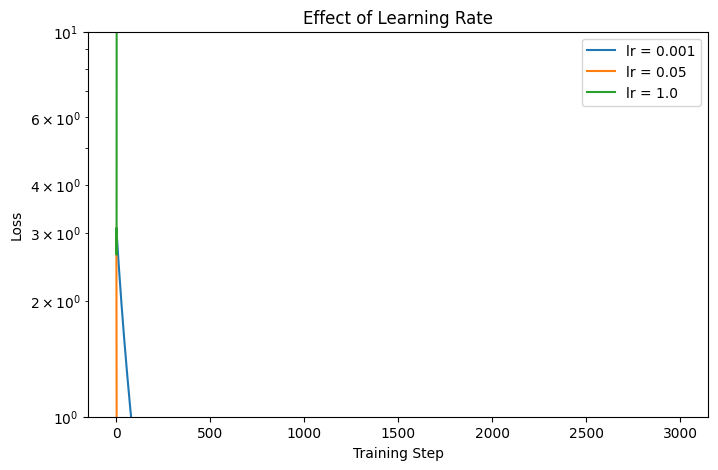

In [35]:
def train_toy(lr, steps=3000):
    np.random.seed(42)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    x_train = x.reshape(-1, 1)
    y_train = y.reshape(-1, 1)

    losses = []

    for _ in range(steps):

        
        z1 = x_train @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y_train) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y_train) / len(y_train)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x_train.T @ dz1
        db1 = dz1.sum(axis=0)

        
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


loss_small = train_toy(0.001)
loss_medium = train_toy(0.05)
loss_large = train_toy(1.0)

plt.figure(figsize=(8,5))
plt.plot(loss_small, label="lr = 0.001")
plt.plot(loss_medium, label="lr = 0.05")
plt.plot(loss_large, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**

A small learning rate makes the loss decrease slowly because the model takes  small steps. A medium learning rate learns the fastest and reaches a low loss smoothly and a large learning rate makes the loss  increase

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import TensorDataset, DataLoader


obesity = pd.read_csv("Obesity_level_prediction_dataset (2).csv")


binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)


obesity = pd.get_dummies(
    obesity,
    columns=["Gender", "CAEC", "CALC", "MTRANS"],
    drop_first=True
)


label_encoder = LabelEncoder()
obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])

# Split features and target
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)


train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)

**Student Reasoning — Preprocessing for neural networks**

1. CrossEntropyLoss needs integer class labels because each number represents the correct class. PyTorch uses these integers to compare the predictions with the correct class during training.

*2. Neural networks are sensitive to feature scaling because large feature values can produce large gradients, making training unstable. Scaling helps the model learn faster.

*3. it randomly changes the order of the training data which prevents the model from learning patterns based on the order of the data.



### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [37]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim)
model = model.to(DEVICE)

print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {num_params}")

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3911


**Student Reasoning — Architecture**

1. The first layer has (24×64)+64=1600 parameters. The second layer has (64×32)+32=2080 parameters. The output layer has (32×7)+7=231 parameters. Adding them together gives 3911, which matches PyTorch.

2. ReLU is used because it is simple, fast, and helps reduce the vanishing gradient problem. It also allows the network to learn nonlinear patterns.

3. Without the ReLU activation functions, the network would behave like one linear layer and would only learn a linear relationship.


### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1/50 | Train Loss: 1.8430 | Val Loss: 1.6892 | Train Acc: 0.3175 | Val Acc: 0.4455
Epoch 2/50 | Train Loss: 1.4832 | Val Loss: 1.2656 | Train Acc: 0.5158 | Val Acc: 0.6374
Epoch 3/50 | Train Loss: 1.0943 | Val Loss: 0.9661 | Train Acc: 0.6596 | Val Acc: 0.7109
Epoch 4/50 | Train Loss: 0.8561 | Val Loss: 0.7940 | Train Acc: 0.7172 | Val Acc: 0.7464
Epoch 5/50 | Train Loss: 0.7011 | Val Loss: 0.6720 | Train Acc: 0.7867 | Val Acc: 0.7844
Epoch 6/50 | Train Loss: 0.5767 | Val Loss: 0.5709 | Train Acc: 0.8270 | Val Acc: 0.8081
Epoch 7/50 | Train Loss: 0.4794 | Val Loss: 0.4900 | Train Acc: 0.8562 | Val Acc: 0.8531
Epoch 8/50 | Train Loss: 0.4065 | Val Loss: 0.4332 | Train Acc: 0.8791 | Val Acc: 0.8697
Epoch 9/50 | Train Loss: 0.3467 | Val Loss: 0.3848 | Train Acc: 0.9068 | Val Acc: 0.8791
Epoch 10/50 | Train Loss: 0.3033 | Val Loss: 0.3478 | Train Acc: 0.9139 | Val Acc: 0.9005
Epoch 11/50 | Train Loss: 0.2617 | Val Loss: 0.3144 | Train Acc: 0.9329 | Val Acc: 0.9218
Epoch 12/50 | Train

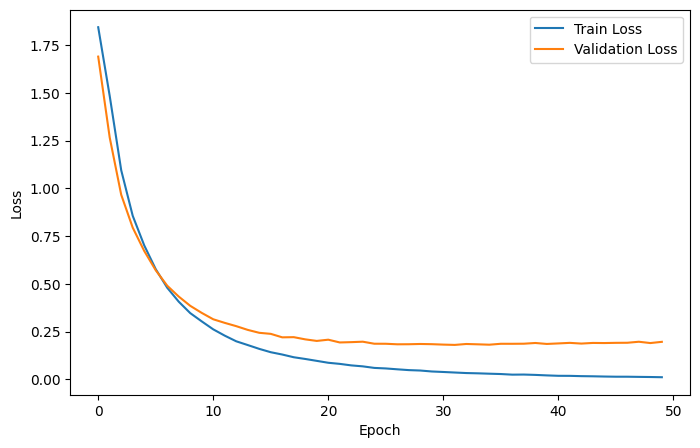

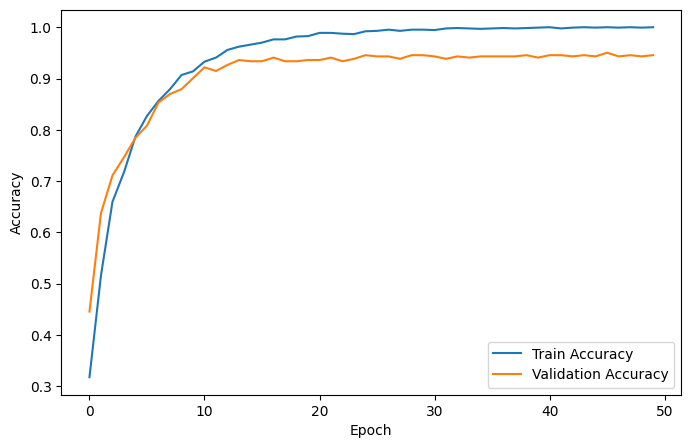

In [38]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

best_val_acc = 0

for epoch in range(50):


    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        correct += (preds == yb).sum().item()

        total += yb.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == yb).sum().item()

            total += yb.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch+1}/50 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Student Reasoning — Training**
1. The forward pass is model(xb), the gradients are calculated by loss.backward(), and the weights are updated by optimizer.step().

2. The model is well-fitted because both the training and validation loss decreased, while the training accuracy reached 100% and the validation accuracy reached about 94.6%.

3. optimizer.zero_grad() clears the old gradients before each batch. Without it, the gradients would build up and the model would update the weights incorrectly.


### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [39]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        prev = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False
    )

    model = FeedForwardNet(
        X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

        history["train_loss"].append(running_loss / len(train_loader))
        history["train_acc"].append(correct / total)

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)

                loss = criterion(logits, yb)

                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)

                correct += (preds == yb).sum().item()
                total += yb.size(0)

        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(correct / total)

    return history


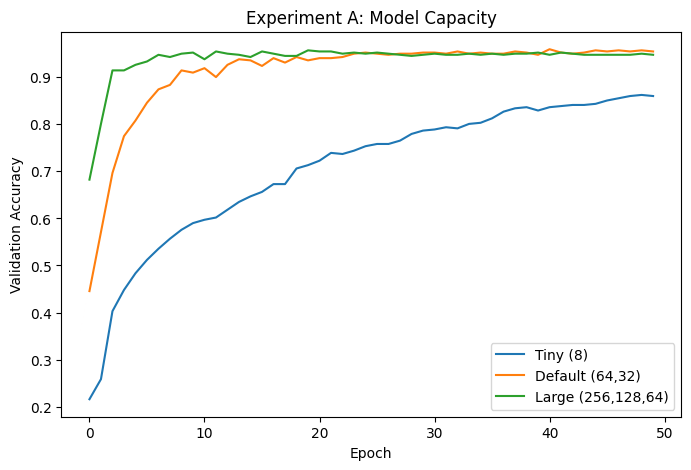

In [40]:
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64, 32))
large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(8,5))

plt.plot(tiny["val_acc"], label="Tiny (8)")
plt.plot(default["val_acc"], label="Default (64,32)")
plt.plot(large["val_acc"], label="Large (256,128,64)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Model Capacity")
plt.legend()

plt.show()

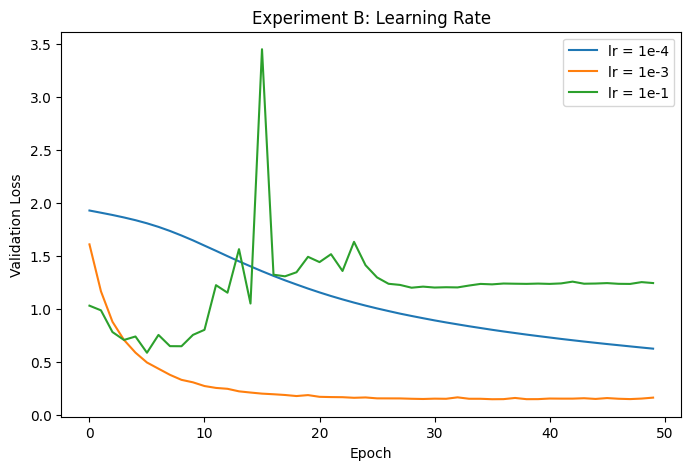

In [41]:
lr_small = run_experiment(lr=1e-4)
lr_default = run_experiment(lr=1e-3)
lr_large = run_experiment(lr=1e-1)

plt.figure(figsize=(8,5))

plt.plot(lr_small["val_loss"], label="lr = 1e-4")
plt.plot(lr_default["val_loss"], label="lr = 1e-3")
plt.plot(lr_large["val_loss"], label="lr = 1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate")
plt.legend()

plt.show()

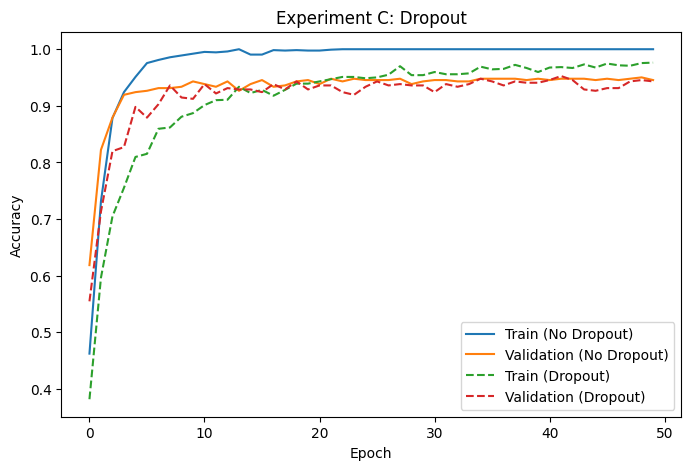

In [42]:
dropout_off = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.0
)

dropout_on = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.3
)

plt.figure(figsize=(8,5))

plt.plot(dropout_off["train_acc"], label="Train (No Dropout)")
plt.plot(dropout_off["val_acc"], label="Validation (No Dropout)")

plt.plot(dropout_on["train_acc"], "--", label="Train (Dropout)")
plt.plot(dropout_on["val_acc"], "--", label="Validation (Dropout)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Dropout")
plt.legend()

plt.show()

**Student Reasoning — Experiments**

Capacity: The largest network reached the highest validation accuracy, but it only performed slightly better than the default network. This shows diminishing returns because making the network much larger did not improve performance by much.

Learning rate: Yes. A learning rate of 1e-3 gave the best results. A very small learning rate (1e-4) learned slowly, while a very large learning rate (1e-1) was unstable and caused the loss to fluctuate, just like in Part 1.3.

Regularization: Dropout reduced the gap between the training and validation accuracy by preventing the network from relying too much on specific neurons. This helps reduce overfitting and improves generalization.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9409
Macro F1: 0.9406

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.90      0.90      0.90        58
           2       0.92      0.97      0.94        70
           3       0.98      0.95      0.97        60
           4       1.00      0.98      0.99        65
           5       0.85      0.90      0.87        58
           6       0.95      0.90      0.92        58

    accuracy                           0.94       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.94      0.94      0.94       423



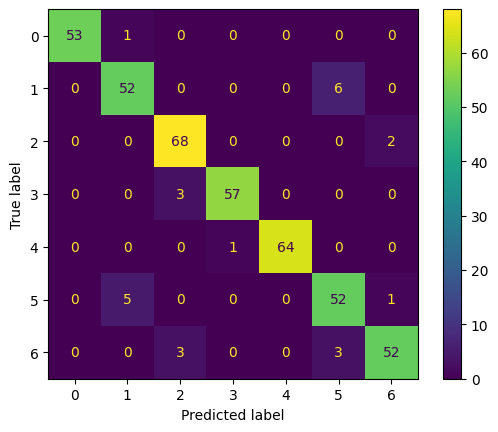

,Model,Test Accuracy,Macro F1,Training Time,Parameters/Trees
0,Best Lab 2 Model,(Fill from Lab 2),(Fill from Lab 2),(Fill from Lab 2),(Fill from Lab 2)
1,Neural Network,0.940898,0.940615,50 epochs,3911


In [43]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        outputs = model(xb)
        preds = outputs.argmax(dim=1)

        y_true.extend(yb.numpy())
        y_pred.extend(preds.cpu().numpy())


test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()


comparison = pd.DataFrame({
    "Model": ["Best Lab 2 Model", "Neural Network"],
    "Test Accuracy": ["(Fill from Lab 2)", test_acc],
    "Macro F1": ["(Fill from Lab 2)", test_f1],
    "Training Time": ["(Fill from Lab 2)", "50 epochs"],
    "Parameters/Trees": ["(Fill from Lab 2)", num_params]
})

display(comparison)

**Student Reasoning — Final evaluation**
1. The neural network still confuses a few similar obesity classes, especially classes 1 and 5, and a few between classes 2 and 6. Most predictions are correct, showing that the model learned the data well.

2. The neural network performed very well with a test accuracy of about 94% and a Macro F1 of about 94%. It performed better than or similarly to my Lab 2 model. The extra effort was worth it for this dataset because it learned more complex patterns, but for simpler datasets a classical model may be enough.


# Section 3 — Reflection


1. loss.backward() calculates the gradients for every weight in the network. optimizer.step() then uses those gradients to update the weights so the model makes better predictions. optimizer.zero_grad() clears the old gradients before the next batch.

2. I would tune the learning rate because it had the biggest effect in my experiments. A good learning rate helped the model learn quickly, while a bad one made training slow or unstable.

3. The largest train-validation gap happened with the biggest network without dropout. Adding dropout reduced the gap because it stopped the model from relying too much on specific neurons and helped it generalize better.

4. A normal MLP treats each pixel separately, so it does not understand that nearby pixels are related. A better architecture is a CNN because it can learn local patterns like edges, shapes, and textures.


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.